# Movie Industry Investment Strategy: A Data-Driven Approach to Production

The film industry offers massive financial upside, but production is inherently high-risk. A blockbuster can generate billions, while an expensive misfire can destroy capital.

## The Core Investment Question:
Given limited production capital, which budgets, release windows, and genres offer the strongest opportunity for financial performance?

This analysis evaluates historical production budgets, worldwide box-office revenue, and IMDb audience ratings to uncover repeatable patterns for smarter production decisions.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_csv('tn.movie_budgets.csv')

# Clean monetary columns
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
    df[col] = df[col].str.replace(r'\$|,', '', regex=True).str.strip().astype('int64')

# Extract date features
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_month'] = df['release_date'].dt.month
df['release_year'] = df['release_date'].dt.year

# Filter for movies released in 2010 or later to match IMDb data
df = df[df['release_year'] >= 2010]

# Calculate financial metrics
df['net_profit'] = df['worldwide_gross'] - df['production_budget']
df['gross_roi'] = ((df['worldwide_gross'] - df['production_budget']) / df['production_budget']) * 100

# Display results
df[['movie', 'production_budget', 'worldwide_gross', 'net_profit', 'gross_roi']].head()

,movie,production_budget,worldwide_gross,net_profit,gross_roi
1,Pirates of the Caribbean: On Stranger Tides,410600000,1045663875,635063875,154.667286
2,Dark Phoenix,350000000,149762350,-200237650,-57.210757
3,Avengers: Age of Ultron,330600000,1403013963,1072413963,324.384139
4,Star Wars Ep. VIII: The Last Jedi,317000000,1316721747,999721747,315.369636
5,Star Wars Ep. VII: The Force Awakens,306000000,2053311220,1747311220,571.016739


## 01 Defining Investment Success

A movie earning $500 million sounds successful, but its financial attractiveness depends entirely on its production cost. Therefore, we evaluate success using two distinct metrics:

* **Net Profit**: How many absolute dollars remain after recovering the production budget?

* **Gross ROI**: How efficiently was the production capital converted into revenue?

_Business implication_: The highest-grossing movie is not necessarily the most efficient investment.

## 02 Does Release Timing Matter?

A strong movie can underperform if released into a weak demand window. We examine historical box-office medians by month to identify optimal release timing while controlling for blockbuster skew.

In [10]:
monthly_performance = (
    df.groupby('release_month')['worldwide_gross']
      .agg(['mean', 'median', 'count'])
      .sort_index()
)

# Convert revenue to millions
monthly_performance[['mean', 'median']] /= 1e6

monthly_performance

,mean,median,count
release_month,,,
1,59.351475,31.161330,166
2,94.474706,40.454520,179
3,106.716717,20.790486,207
4,82.572229,16.671517,198
5,170.432418,35.807724,170
6,163.753770,23.555332,184
7,162.942254,40.671622,170
8,71.448896,33.822672,196
9,55.635130,18.877153,203


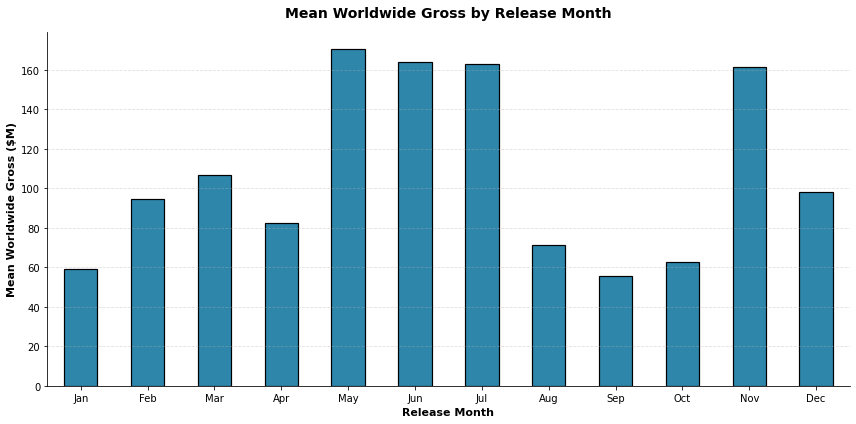

In [12]:
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
bars = monthly_performance['mean'].plot(kind='bar', color='#2E86AB', 
                                          edgecolor='black', linewidth=1.2)
plt.title('Mean Worldwide Gross by Release Month', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Release Month', fontsize=11, fontweight='bold')
plt.ylabel('Mean Worldwide Gross ($M)', fontsize=11, fontweight='bold')
plt.xticks(range(12), month_labels, rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Timing Takeaway 
Release timing significantly influences baseline commercial opportunity, with clear peaks in early summer and late year. However, revenue timing must be paired with cost-efficiency.

To understand investment efficiency, we must evaluate performance by Genre.

## 03  Where Should the Studio Invest?

Revenue alone does not tell us where capital is being used most efficiently.
A genre that generates moderate revenue with relatively modest budgets may be a more attractive investment than a genre that generates enormous revenue but requires enormous spending.

### Integrating IMDb Data

We combine the financial dataset with IMDb genre and audience-rating information to evaluate both **financial performance** and **audience reception**.

In [13]:
import sqlite3
import pandas as pd

# Load IMDb data
conn = sqlite3.connect('im.db')
df_basics = pd.read_sql('SELECT movie_id, primary_title, genres FROM movie_basics', conn)
df_ratings = pd.read_sql('SELECT movie_id, averagerating, numvotes FROM movie_ratings', conn)
conn.close()

### Data Quality Note

The financial and IMDb datasets do not share a universal movie identifier, so **titles are used for matching**.
This introduces potential issues involving:

- duplicate movie titles
- spelling differences
- unmatched movies
- different versions of similarly titled films

Therefore, the results should be interpreted as **directional evidence rather than a definitive accounting of every film.**

## 04 Which Genres Deliver the Best Returns?

Because extreme blockbuster returns can artificially inflate genre averages, we use Median Gross ROI. This provides a robust estimate of typical baseline performance per genre category.

In [14]:
# Match financial data ('movie') with IMDb data ('primary_title')
df_final = df.merge(df_basics, left_on='movie', right_on='primary_title', how='inner')

# Merge the ratings data as well for your final analysis dimension
df_final = df_final.merge(df_ratings, on='movie_id', how='inner')

# Now your genre_roi calculation will work perfectly:
genre_roi = (df_final
             .assign(genre_list=df_final['genres'].str.split(','))
             .explode('genre_list')
             .groupby('genre_list')['gross_roi']
             .median()
             .sort_values(ascending=False))

genre_roi.head(10)

genre_list
Animation    179.032229
Sci-Fi       137.044727
Adventure    135.895145
Mystery      132.559592
Fantasy      109.709384
Comedy       106.344667
Romance      105.121590
Family        96.888367
Action        81.514721
Biography     74.678187
Name: gross_roi, dtype: float64

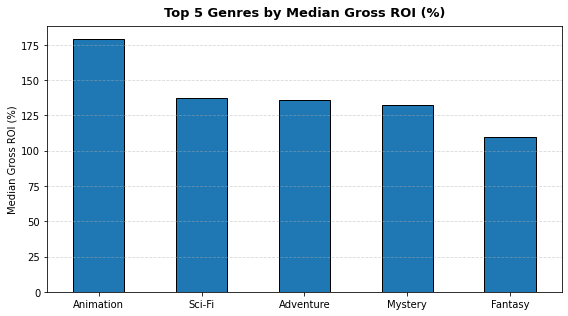

In [15]:
plt.figure(figsize=(8, 4.5))
genre_roi.head(5).plot(kind='bar', color='#1f77b4', edgecolor='black')

plt.title('Top 5 Genres by Median Gross ROI (%)', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('')
plt.ylabel('Median Gross ROI (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

###  Investment Signal

In this sample, **Animation, Mystery, and Adventure** emerge among the highest-performing genres by median Gross ROI.

> **Business implication:** Genre selection offers an opportunity to improve capital efficiency without relying exclusively on blockbuster-scale budgets.

But this creates an even more important question: **Does spending more actually improve the probability of success?**

## 05 Does Spending More Actually Buy Success?

Large productions require significantly more capital. The standard assumption is:
> **Bigger budget → Bigger movie → Bigger revenue → Better audience reception**

We examine this by testing Production Budget against three metrics:
1. **Worldwide Gross** (Revenue)
2. **IMDb Rating** (Reception)
3. **Gross ROI** (Efficiency)

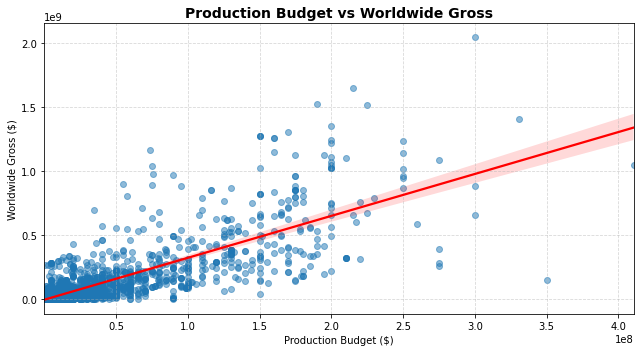

In [16]:
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df_final, x='production_budget', y='worldwide_gross',
    scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}
)

plt.title('Production Budget vs Worldwide Gross', fontsize=14, fontweight='bold')
plt.xlabel('Production Budget ($)')
plt.ylabel('Worldwide Gross ($)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

> * Budget can raise the revenue ceiling, but it does not eliminate uncertainty.

A positive relationship exists, but correlation does not mean that additional spending guarantees proportional revenue growth.

## 06 Does More Spending Produce Better Movies?

Financial success is only part of the story. We now examine whether higher production costs are associated with better **IMDb audience ratings**.

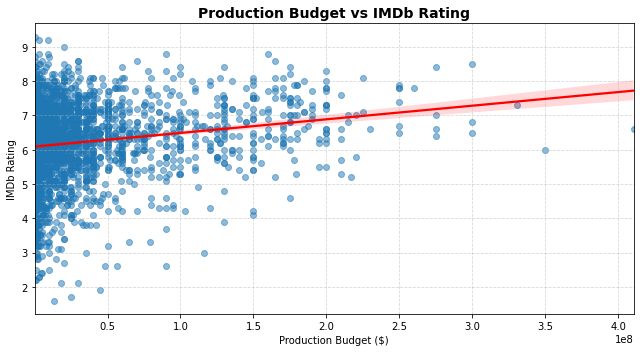

Pearson correlation: 0.175
Spearman correlation: 0.157


In [18]:
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df_final, x='production_budget', y='averagerating',
    scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}
)

plt.title('Production Budget vs IMDb Rating', fontsize=14, fontweight='bold')
plt.xlabel('Production Budget ($)')
plt.ylabel('IMDb Rating')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Calculate and print correlations
p_corr = df_final['production_budget'].corr(df_final['averagerating'], method='pearson')
s_corr = df_final['production_budget'].corr(df_final['averagerating'], method='spearman')

print(f"Pearson correlation: {p_corr:.3f}")
print(f"Spearman correlation: {s_corr:.3f}")
df_final.to_csv('final_cleaned_movie_data.csv', index=False)

### Interpretation

> **Business implication:** Higher production costs should not be treated as a reliable proxy for higher audience satisfaction.

Correlations near zero suggest that while money can buy scale, visual effects, and spectacle, it does not necessarily buy a better-received story.

In [19]:
import pandas as pd

# Load dataset and explode comma-separated genres into individual rows
df = pd.read_csv('final_cleaned_movie_data.csv')
df['genres'] = df['genres'].str.split(',')
df_exploded = df.explode('genres')
df_exploded['genres'] = df_exploded['genres'].str.strip()

# Save for Tableau
df_exploded.to_csv('final_cleaned_movie_data_exploded.csv', index=False)

# 08 Strategic Investment Framework

| Investment Dimension | Analytical Signal | Strategic Recommendation |
|---|---|---|
| **Genre** | Animation, Mystery & Adventure deliver higher median ROI. | Prioritize high-efficiency genres. |
| **Release Timing** | Certain months demonstrate stronger box-office potential. | Target high-demand release windows. |
| **Production Budget** | Larger budgets increase capital exposure without guaranteed returns. | Maintain disciplined spending. |
| **Audience Reception** | Budget has near-zero correlation with ratings. | Do not equate cost with quality. |
| **ROI** | Revenue scale and investment efficiency are distinctly different. | Optimize capital efficiency. |

# 09 Final Investment Thesis & Recommendation

> ## **The strongest movie investment strategy is not to spend the most — it is to spend intelligently.**

Successful movie investment requires balancing upside, audience appeal, and capital efficiency. A data-driven studio should:

1. **Target high-efficiency genres**
2. **Release strategically**
3. **Control production costs**
4. **Evaluate success using ROI rather than revenue alone**


# 10 Limitations & Next Steps

This analysis provides **directional investment insights**. Gross ROI here excludes marketing (P&A), distribution expenses, theater revenue-sharing, and streaming backend.

### Next Steps for a Predictive Model
A second-stage model to estimate the expected return of a proposed movie should incorporate:
- Marketing budgets & franchise/sequel status
- Director/cast historical performance & studio
- Release competition & inflation-adjusted revenue
